# Fish Market – Regression mit echten Daten (Step-by-Step)

https://www.kaggle.com/datasets/vipullrathod/fish-market

Ziel: **Gewicht (Weight)** mit echten Messdaten vorhersagen und sehen, wie sich **Feature-Auswahl** auf **R²** auswirkt.

Du lernst dabei:
- CSV laden & Daten prüfen
- Train/Test Split (warum und wie)
- Lineare Regression trainieren
- **MSE** und **R²** interpretieren
- Feature-Sets vergleichen (einzeln / kombiniert)
- Warum 3 Längen stark korreliert sind (Multikollinearität)
- Optional: **Adjusted R²** als fairerer Vergleich

> **Voraussetzung:** Lege `./data/Fish.csv`


In [3]:
# 0) Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)


## 1) Daten laden

Wenn die Datei nicht im selben Ordner liegt, passe den Pfad an.


In [4]:
CSV_PATH = "./data/Fish.csv"  # ggf. anpassen, z.B. "data/Fish.csv"
df = pd.read_csv(CSV_PATH)

df.head()


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


## 2) Überblick: Spalten & fehlende Werte

Wir checken:
- Welche Spalten gibt es?
- Gibt es Missing Values?
- Welche Datentypen?


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [6]:
df.isna().sum()


Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

## 3) Kurze Datenbeschreibung

Für Regression brauchen wir numerische Features. In diesem Dataset sind typisch:

- Zielvariable (**y**): `Weight`
- Numerische Features (**X**): `Length1`, `Length2`, `Length3`, `Height`, `Width`
- Kategorial: `Species` (später optional mit One-Hot-Encoding, wenn du willst)


In [27]:
df.describe(numeric_only=True)

TypeError: NDFrame.describe() got an unexpected keyword argument 'numeric_only'

## 4) Korrelationen der numerischen Features

Je näher der Wert an **1**, desto stärker hängen die Variablen linear zusammen.


In [11]:
numeric_cols = ["Weight", "Length1", "Length2", "Length3", "Height", "Width"]
corr = df[numeric_cols].corr()

corr


,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507
Length1,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050
Length2,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547
Length3,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520
Height,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881
Width,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000


### 4.1 Korrelation als Heatmap (Visualisierung)

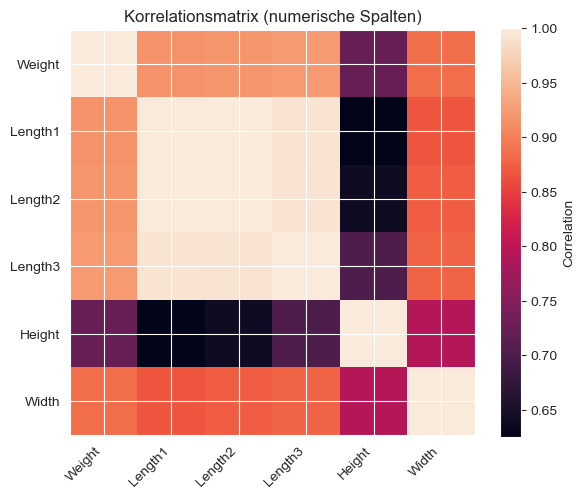

In [12]:
plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation="nearest")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar(label="Correlation")
plt.title("Korrelationsmatrix (numerische Spalten)")
plt.tight_layout()
plt.show()


## 5) Train-Test-Split

Wir teilen die Daten in:
- **Train**: Modell lernt Zusammenhänge
- **Test**: Modell wird auf *unbekannten* Daten bewertet

Wichtig: Wir vergleichen R² immer auf dem **Testset**.


In [15]:
# Grund-Setup: Zielvariable
y = df["Weight"]

# Wir starten mit einem einfachen Feature-Set (nur Length1)
X = df[["Length1"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42    # 80%training 20%testing random -> shuffle=false
)

X_train.shape, X_test.shape


((127, 1), (32, 1))

## 6) Visualisierung der Daten

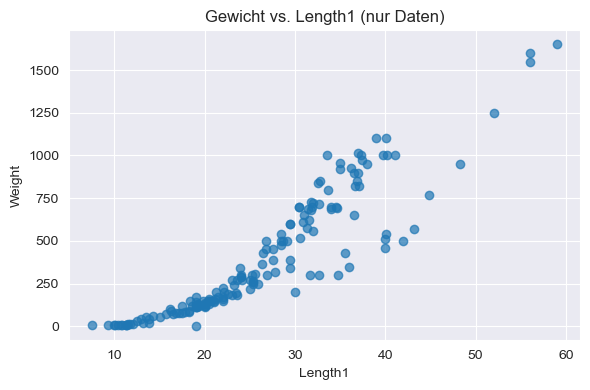

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(df["Length1"], df["Weight"], alpha=0.7)

plt.xlabel("Length1")
plt.ylabel("Weight")
plt.title("Gewicht vs. Length1 (nur Daten)")
plt.tight_layout()
plt.show()

## 7) Lineare Regression trainieren (1 Feature: Length1)

Wir trainieren:
$ Weight \approx a \cdot Length1 + b $

- **a** = Koeffizient (Steigung): „Wie viele Gramm pro zusätzlichem cm?“
- **b** = Intercept/Bias: Achsenabschnitt


In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Koeffizient (a):", model.coef_[0])
print("Bias / Intercept (b):", model.intercept_)


Koeffizient (a): 32.44308998291232
Bias / Intercept (b): -464.13411600851134


$ Weight=32.44⋅Length1−464.13 $

> Was bedeutet das ?


## 8) Vorhersagen & Metriken (MSE, R²)

- **MSE**: mittlerer quadratischer Fehler (kleiner ist besser)
- **R²**: Anteil der erklärten Varianz (1 = perfekt, 0 = wie Mittelwert, <0 = schlechter als Mittelwert)


In [18]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R²-Score:", r2)
print("RMSE (sqrt(MSE)):", np.sqrt(mse))


Mean Squared Error (MSE): 26796.684740821383
R²-Score: 0.8116084146869397
RMSE (sqrt(MSE)): 163.69692953999285


$RMSE=\sqrt{MSE}$
- Vorhersage liegt im Durchschnitt etwa 164 Gramm daneben.
    - Kleine Fische: ~200g
    - Große Fische: ~1000g+

- Ein Fehler von 164g ist:
    - relativ groß bei kleinen Fischen
    - relativ klein bei großen Fischen

## 9) Visualisierung: Daten + Regressionsgerade (Length1 → Weight)

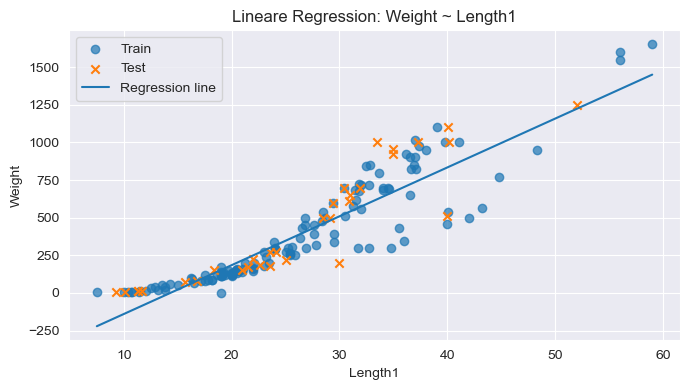

In [19]:
plt.figure(figsize=(7,4))
plt.scatter(X_train["Length1"], y_train, alpha=0.7, label="Train")
plt.scatter(X_test["Length1"], y_test, marker="x", label="Test")

x_line = np.linspace(df["Length1"].min(), df["Length1"].max(), 200)
x_line_df = pd.DataFrame({"Length1": x_line})
y_line = model.predict(x_line_df)

plt.plot(x_line, y_line, label="Regression line")
plt.xlabel("Length1")
plt.ylabel("Weight")
plt.title("Lineare Regression: Weight ~ Length1")
plt.legend()
plt.tight_layout()
plt.show()


## 10) Feature-Sets vergleichen (R² auf dem Testset)

Wir definieren eine Evaluationsfunktion und vergleichen verschiedene Feature-Sets.
Optional berechnen wir **Adjusted R²** (fairer bei unterschiedlicher Feature-Anzahl).


In [20]:
def adjusted_r2(r2, n_samples, n_features):
    n = n_samples
    p = n_features
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def evaluate_feature_set(feature_list, test_size=0.2, random_state=42):
    X = df[feature_list]
    y = df["Weight"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    adj = adjusted_r2(r2, n_samples=len(y_test), n_features=len(feature_list))
    return {"features": feature_list, "mse": mse, "rmse": float(np.sqrt(mse)), "r2": r2, "adj_r2": adj}


### 10.1 Feature-Sets definieren

In [21]:
feature_sets = [
    ["Length1"],
    ["Length2"],
    ["Length3"],
    ["Height"],
    ["Width"],
    ["Length1", "Length2", "Length3"],
    ["Length1", "Length2", "Length3", "Height", "Width"],
]

results = [evaluate_feature_set(fs) for fs in feature_sets]
res_df = pd.DataFrame(results).sort_values("r2", ascending=False)

res_df


,features,mse,rmse,r2,adj_r2
6,"[Length1, Length2, Length3, Height, Width]",16763.887193,129.475431,0.882143,0.859478
2,[Length3],21835.271889,147.767628,0.846489,0.841372
5,"[Length1, Length2, Length3]",22666.611432,150.554347,0.840645,0.823571
4,[Width],24143.054379,155.380354,0.830265,0.824607
1,[Length2],25604.524458,160.014138,0.819990,0.813989
0,[Length1],26796.684741,163.696930,0.811608,0.805329
3,[Height],45896.947811,214.235730,0.677326,0.666570


### 10.2 R² (und Adjusted R²) plotten

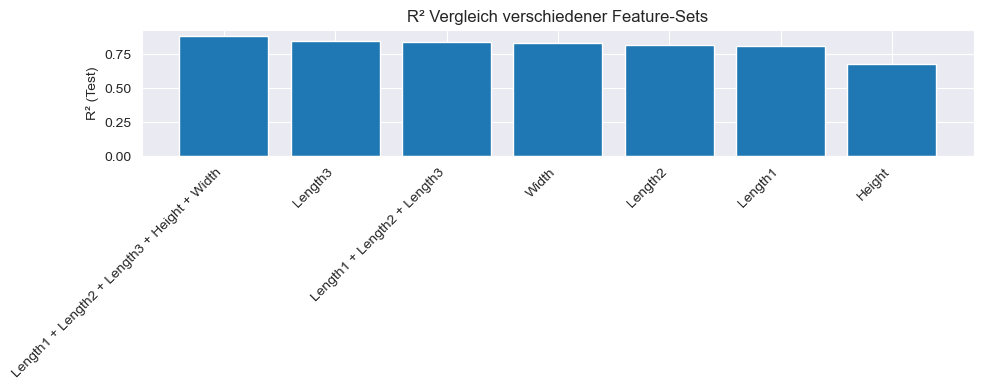

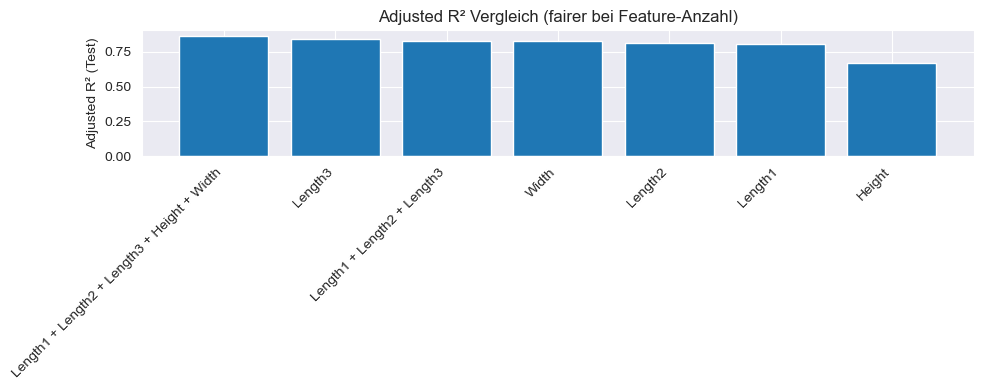

In [22]:
labels = [" + ".join(r["features"]) for r in results]
r2_vals = [r["r2"] for r in results]
adj_vals = [r["adj_r2"] for r in results]

order = np.argsort(r2_vals)[::-1]
labels_sorted = [labels[i] for i in order]
r2_sorted = [r2_vals[i] for i in order]
adj_sorted = [adj_vals[i] for i in order]

plt.figure(figsize=(10,4))
plt.bar(range(len(labels_sorted)), r2_sorted)
plt.xticks(range(len(labels_sorted)), labels_sorted, rotation=45, ha="right")
plt.ylabel("R² (Test)")
plt.title("R² Vergleich verschiedener Feature-Sets")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.bar(range(len(labels_sorted)), adj_sorted)
plt.xticks(range(len(labels_sorted)), labels_sorted, rotation=45, ha="right")
plt.ylabel("Adjusted R² (Test)")
plt.title("Adjusted R² Vergleich (fairer bei Feature-Anzahl)")
plt.tight_layout()
plt.show()


## 11) Redundanz der 3 Längen (Multikollinearität)

In [23]:
df[["Length1", "Length2", "Length3"]].corr()


,Length1,Length2,Length3
Length1,1.000000,0.999517,0.992031
Length2,0.999517,1.000000,0.994103
Length3,0.992031,0.994103,1.000000


## Ist das gut oder schlecht?!



## 12) Residuen (Fehleranalyse)

Residuen = $y_{true} - y_{pred}$
- um 0 verteilt
- keine klare Struktur


['Length1', 'Length2', 'Length3', 'Height', 'Width']

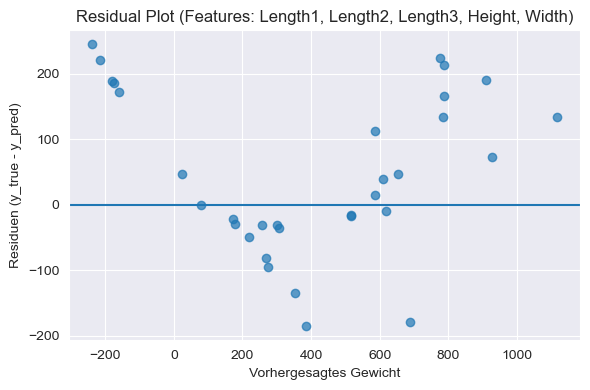

In [29]:
X = df[best_features]
y = df["Weight"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0)
plt.xlabel("Vorhergesagtes Gewicht")
plt.ylabel("Residuen (y_true - y_pred)")
plt.title(f"Residual Plot (Features: {', '.join(best_features)})")
plt.tight_layout()
plt.show()


## Was bedeutet ein Residuum?
Residuum=echtes Gewicht−vorhergesagtes Gewicht

- Punkt über 0 → Modell unterschätzt das Gewicht
- Punkt unter 0 → Modell überschätzt das Gewicht
- Punkt nahe 0 → gute Vorhersage

Biologisch gilt:

$Weight∝Volumen$

Und Volumen wächst nicht linear, sondern näherungsweise kubisch.
Das erklärt die Struktur im Residual Plot.